In [4]:
import pandas as pd
df = pd.read_excel("heart_disease.xlsx",sheet_name="Heart_disease")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


#Exploratory Data Analysis (EDA)

Understand the structure of the dataset by checking its dimensions, data types, and summary statistics.

In [2]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


(908, 13)

#Check Missing Values

Identify whether the dataset contains any missing values.

In [3]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

#Check Duplicate Records

Find duplicate rows in the dataset.

In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


#Histogram

Visualize the distribution of numerical features using histograms.

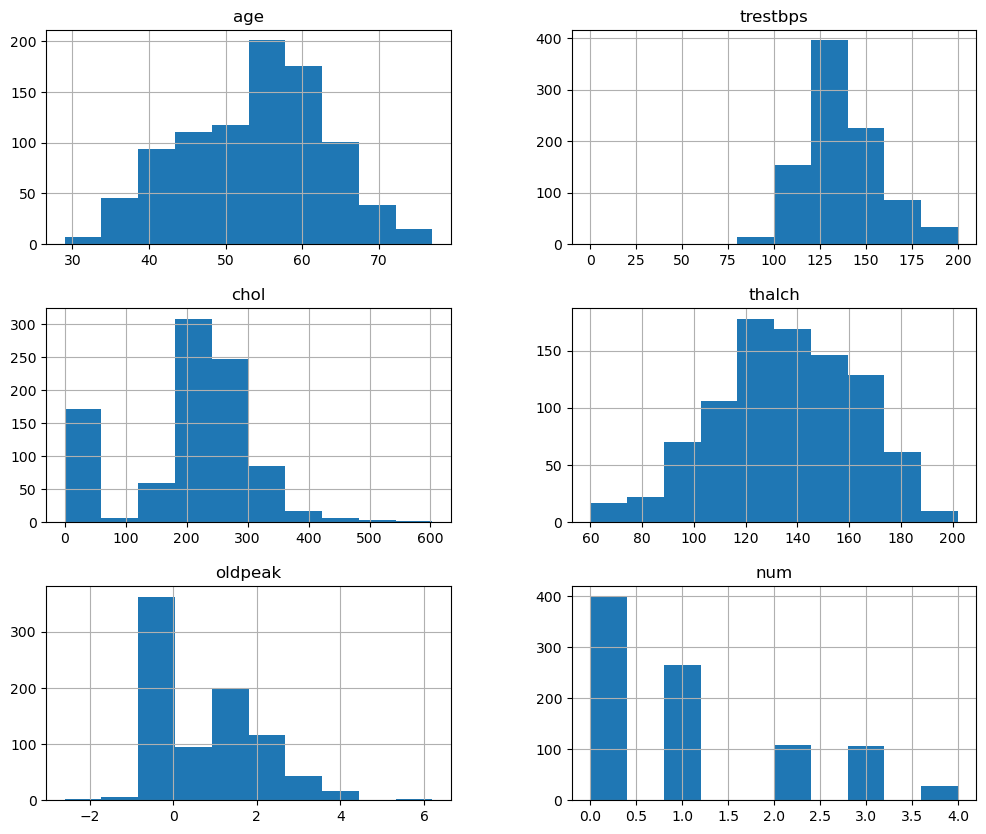

In [16]:
import matplotlib.pyplot as plt
df.hist(figsize=(12,10))
plt.show()

#Box Plot

Visualize outliers present in numerical columns using box plots.

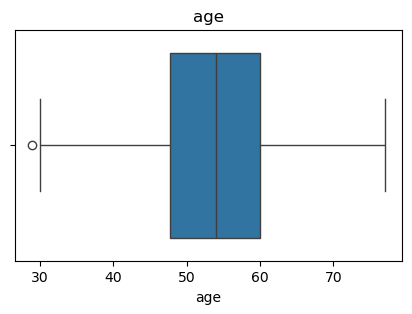

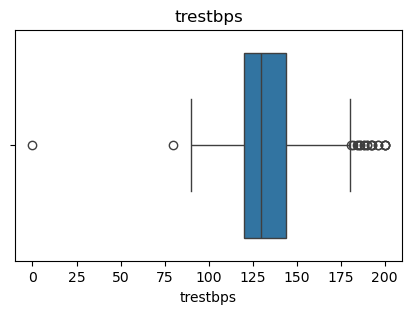

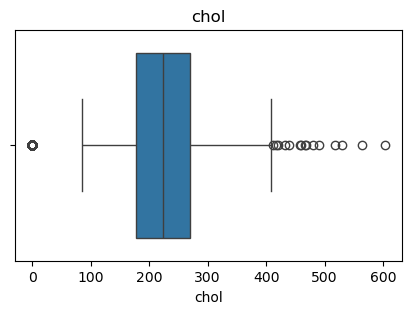

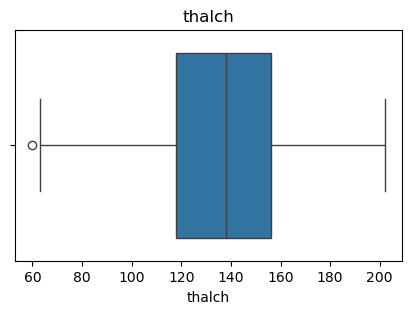

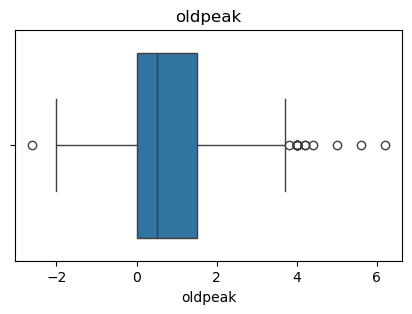

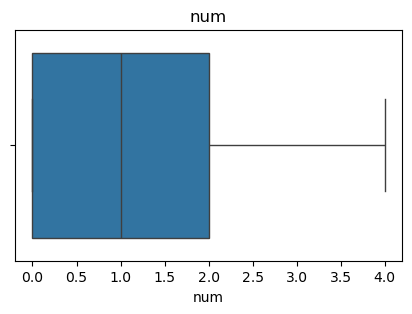

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [22]:
# Select numerical columns except the target column
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('num')

# Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Display new dataset shape
print("Dataset shape after removing outliers:", df.shape)

# Display first 5 rows
df.head()

Dataset shape after removing outliers: (628, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


#Correlation Matrix

Display the correlation between numerical features using a heatmap.

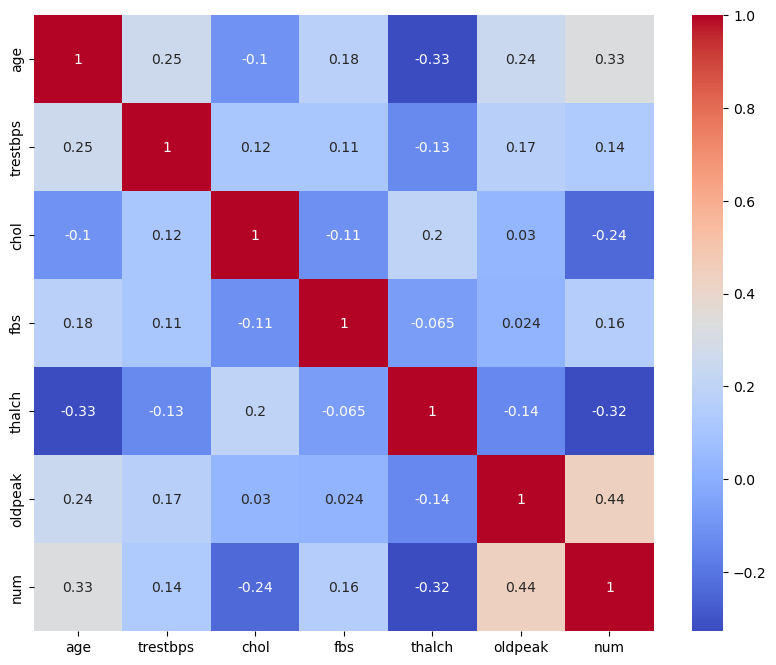

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

#Feature Engineering

Encode categorical variables using Label Encoding.

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,1,2.3,0,0,0
1,41,1,1,135,203,False,1,132,1,0.0,1,0,0
2,57,1,0,140,192,False,1,148,1,0.4,1,0,0
3,52,1,3,118,186,False,0,190,1,0.0,1,0,0
4,57,1,0,110,201,False,1,126,3,1.5,1,0,0


#Feature Selection

Separate the independent variables (X) and dependent variable (y).

In [8]:
X = df.drop("num", axis=1)
y = df["num"]

#Train-Test Split

Split the dataset into training (80%) and testing (20%) sets.

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Decision Tree Classification

Train the Decision Tree Classifier using the training dataset.

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
y_pred = model.predict(X_test)

#Accuracy Score

Evaluate the model using accuracy.

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.69      0.71        89
           1       0.40      0.44      0.42        48
           2       0.29      0.32      0.30        22
           3       0.31      0.29      0.30        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.35      0.35      0.35       182
weighted avg       0.53      0.52      0.52       182



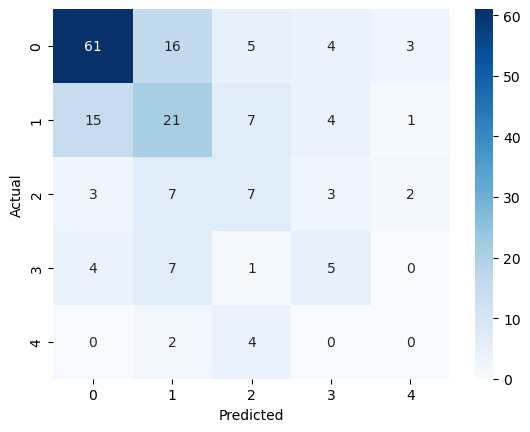

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
import numpy as np
if len(np.unique(y)) == 2:
    prob = model.predict_proba(X_test)[:,1]

    print("ROC-AUC:", roc_auc_score(y_test, prob))

    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()
else:
    print("ROC-AUC is applicable only for binary classification.")

ROC-AUC is applicable only for binary classification.


#Hyperparameter Tuning

Optimize the Decision Tree model using GridSearchCV.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
params = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Best Accuracy:", accuracy_score(y_test, best_pred))

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best Accuracy: 0.5659340659340659


#Best Model

Evaluate the optimized Decision Tree model.

#Feature Importance

Identify the most important features used by the Decision Tree model.

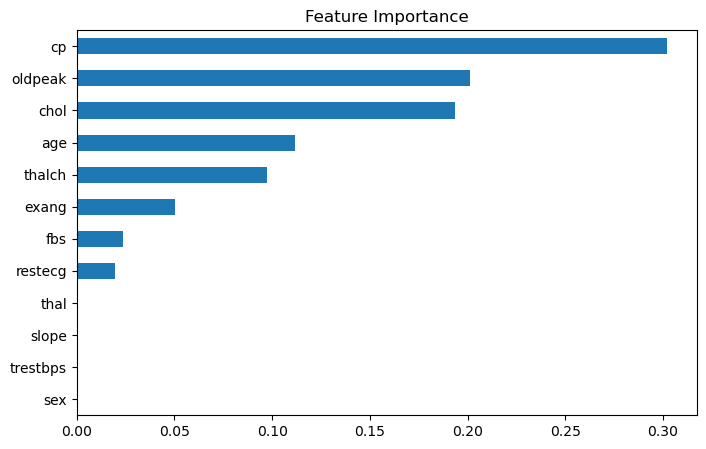

In [27]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance")

plt.show()

#Decision Tree Visualization

Visualize the structure of the trained Decision Tree.

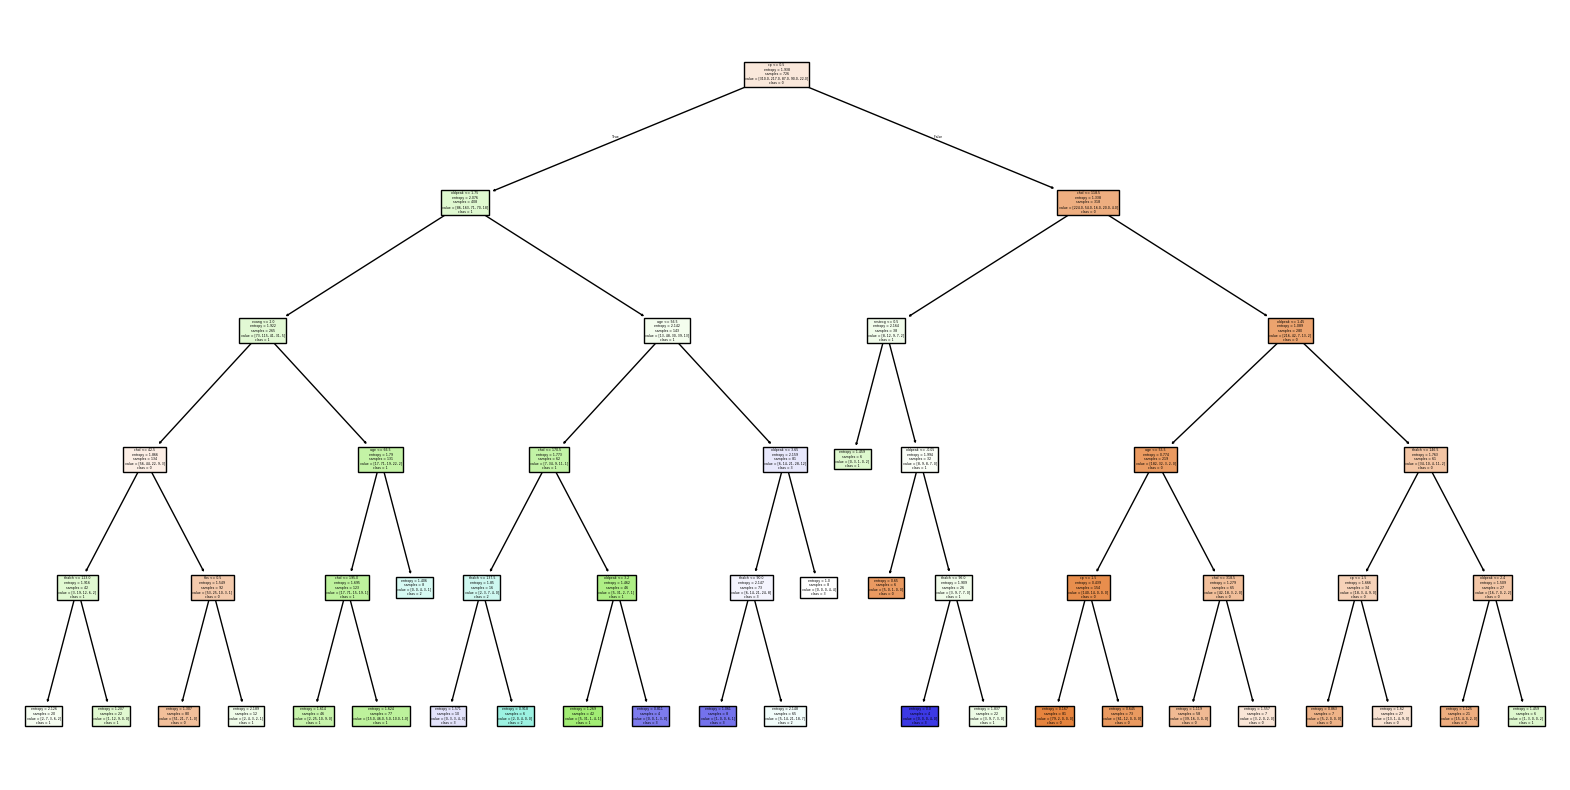

In [28]:
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[str(i) for i in np.unique(y)],
    filled=True
)

plt.show()